In [1]:
import matplotlib.pyplot as plt
import random as rd
import numpy as np
import scipy
from math import *
from scipy.optimize import curve_fit
import os

In [2]:
folder_name = 'data_2024'
folder_path = os.path.abspath(os.path.join(os.getcwd(), '..',folder_name))

In [3]:
def get_distance(position):
    if '2024' in folder_name:
        cuth = lambda T,N: -np.inf
        cutb = lambda T,N: -np.inf
        if position == 'basse' or position == 'Basse': 
            d = 0.41
        elif position == 'haute' or position =='Haute' :
            d= 1.17
    elif '2025' in folder_name:
        cuth = lambda Th,Nh: np.min(Th[Nh>=1])
        cutb = lambda Tb,Nb: np.min(Tb[Nb>=1])

        if position == 'basse' or position == 'Basse': 
            d = (55.5-12.5)/100
        elif position == 'haute' or position =='Haute' :
            d=  (55.5-12.5+72)/100
    return d

In [4]:
print(get_distance('basse'),get_distance('haute'))

0.41 1.17


In [5]:
def linear(x, a, b) : # Fonction liénaire pour la calibration canal-nanoseconde
    return a * x + b


def open_file(position,folder=folder_path) : # Fcontion ouvrant le fichier contenant l'acquisition expérimentale
    file = "spectre_position_" + position + ".txt"
    path= os.path.join(folder, file)
    file = open(path, "r")
    data = file.readlines()
    file.close()
    data = [data[i].split("\n") for i in range(65536)]
    data = [int(data[i][0]) for i in range(65536)]
    return data

def open_file(position, folder=folder_path,filename =None):
    if filename is None:
        filename = f"spectre_position_{position}.txt"
    path = os.path.join(folder, filename)
    if 'Calibration' in filename:
        data = np.loadtxt(path, skiprows=1)
        T = data[:, 0]
        C = data[:, 1]
        return T,C
    else:
        Counts =np.loadtxt(path, dtype=int)
        #C = np.arange(0,len(Counts))
        return Counts

def calibration(time, channel) : # Calibration temporelle de la chaine d'acquisition : canal vers nanoseconde

    par, cov = scipy.optimize.curve_fit(linear, channel, time) # Ajustement linéaire

    a, b = par[0], par[1] # Coefficient directeur et ordonnée à l'origine
    err_a, err_b = np.sqrt(cov[0][0]), np.sqrt(cov[1][1]) # Erreur sur les paramètres d'ajustement
    
    return a, b, err_a, err_b


In [6]:
T,C = open_file('',folder=folder_path,filename='Calibration.txt')
print(T)
print(C)

[ 0.5  1.   2.   4.   8.  12.  16.  20.  24. ]
[ 9769. 10365. 11545. 13792. 18075. 22665. 27070. 31525. 35980.]


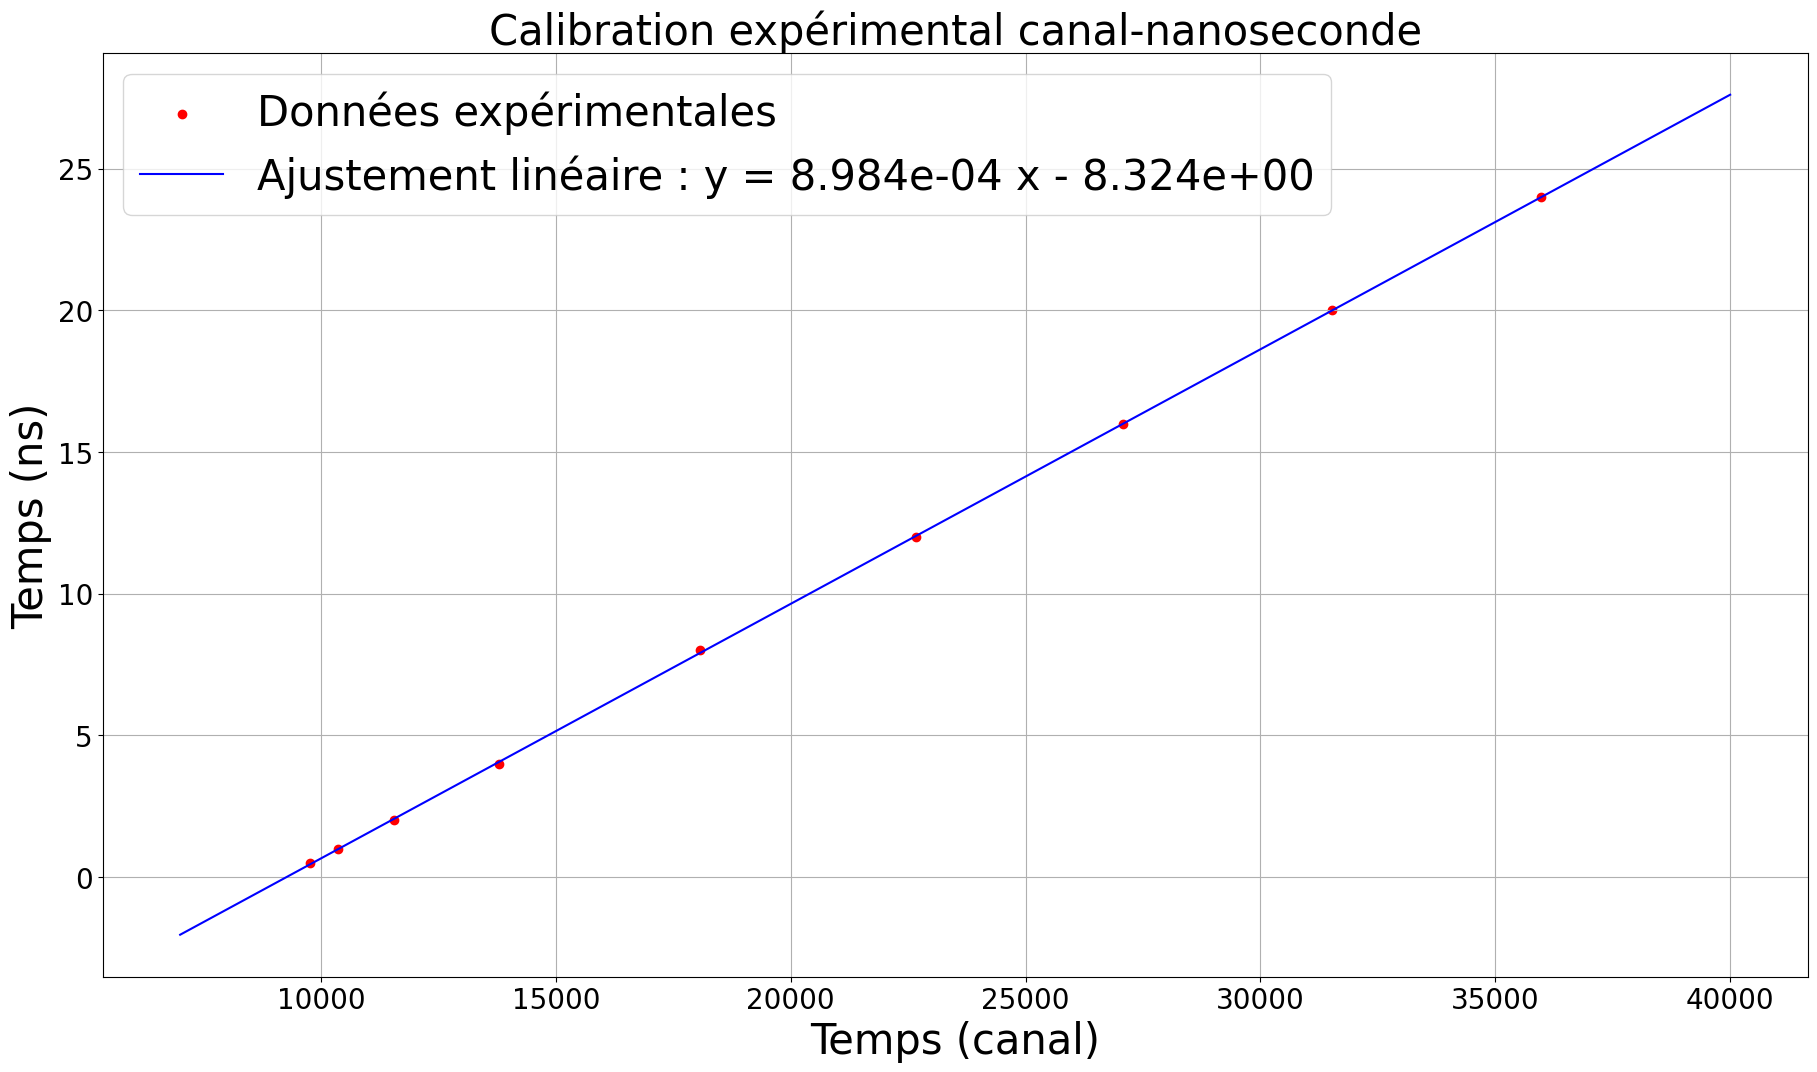

---------- Paramètres pour la calibration ----------
              a = 8.98e-04 +/- 1.84e-06
              b = -8.32e+00 +/- 4.06e-02
----------------------------------------------------


In [7]:
# Calibration temporelle de la chaine d'acquisition : canal vers nanoseconde

if folder_name == 'data_2024':
    channel = [9769, 10365, 11545, 13792, 18075, 22665, 27070, 31525, 35980] # Données en canaux
    time = [0.5, 1, 2, 4, 8, 12, 16, 20, 24] # Données en temps

if folder_name == 'data_2025':
    time = [16,8,4,28] # Données en canaux
    channel = [24650.5,15592.5,10905.5,35380] # Données en temps




adujstment = calibration(time, channel)

plt.figure(figsize = (22, 12))
plt.scatter(channel, time, color = "red", label = "Données expérimentales")
plt.plot(np.linspace(7000, 40000), adujstment[0]*np.linspace(7000, 40000)+adujstment[1], color = "blue", label = r'Ajustement linéaire : y = {:.3e} x - {:.3e}'.format(adujstment[0], np.abs(adujstment[1])))
plt.xlabel("Temps (canal)", fontsize=30)
plt.ylabel("Temps (ns)", fontsize=30)
plt.yticks(fontsize = 20)
plt.xticks(fontsize = 20)
plt.title(r'Calibration expérimental canal-nanoseconde', fontsize = 30)
plt.legend(loc = "best", fontsize = 30)
plt.grid()
plt.show()

print("---------- Paramètres pour la calibration ----------")
print('              a = {:.2e} +/- {:.2e}'.format(adujstment[0], adujstment[2]))
print('              b = {:.2e} +/- {:.2e}'.format(adujstment[1], adujstment[3]))
print("----------------------------------------------------")

In [8]:
adujstment = calibration(time, channel)

Nh = np.array(open_file('haute'))
Th = adujstment[0] * np.linspace(0, len(Nh), len(Nh)) + adujstment[1]

Nb = np.array(open_file('basse'))
Tb = adujstment[0] * np.linspace(0, len(Nb), len(Nb)) + adujstment[1]

if '2024' in folder_name:
    cuth = lambda T,N: -np.inf
    cutb = lambda T,N: -np.inf
elif '2025' in folder_name:
    cuth = lambda Th,Nh: np.min(Th[Nh>=1])
    cutb = lambda Tb,Nb: np.min(Tb[Nb>=1])

    
cuth = cuth(Th,Nh)
cutb = cutb(Tb,Nb)

In [9]:
def gaussian(x, a, mu, sigma,cut=-np.inf) : # Fonction gaussienne pour déterminer le temps moyen de parcours des muons
    res = np.where(x>cut,a*np.exp(-1/2*(x - mu)**2/sigma**2),0)
    return res


def time_average(position, time, channel,cut=-np.inf) : # Fonction calculant le temps moyen selon la position
    adujstment = calibration(time, channel)
    N = np.array(open_file(position))
    T = adujstment[0] * np.linspace(0, len(N), len(N)) + adujstment[1]
    N_safe = np.where(N <= 0, 1.0, N)
    sigma = np.sqrt(N_safe)
    wrapped_gaussian = lambda x, a, mu, sigma: gaussian(x, a, mu, sigma, cut=cut)
    par, cov = scipy.optimize.curve_fit(wrapped_gaussian, T, N, sigma=sigma,bounds=([0, 0, 0], [np.inf, np.inf, np.inf]))

    C, mu, sigma = par[0], par[1], par[2]
    err_C, err_mu, err_sigma = np.sqrt(cov[0][0]), np.sqrt(cov[1][1]), np.sqrt(cov[2][2])

    return C, mu, sigma, err_C, err_mu, err_sigma, N, T


44.17878688975512 11.270167078158625 3.409259961687293


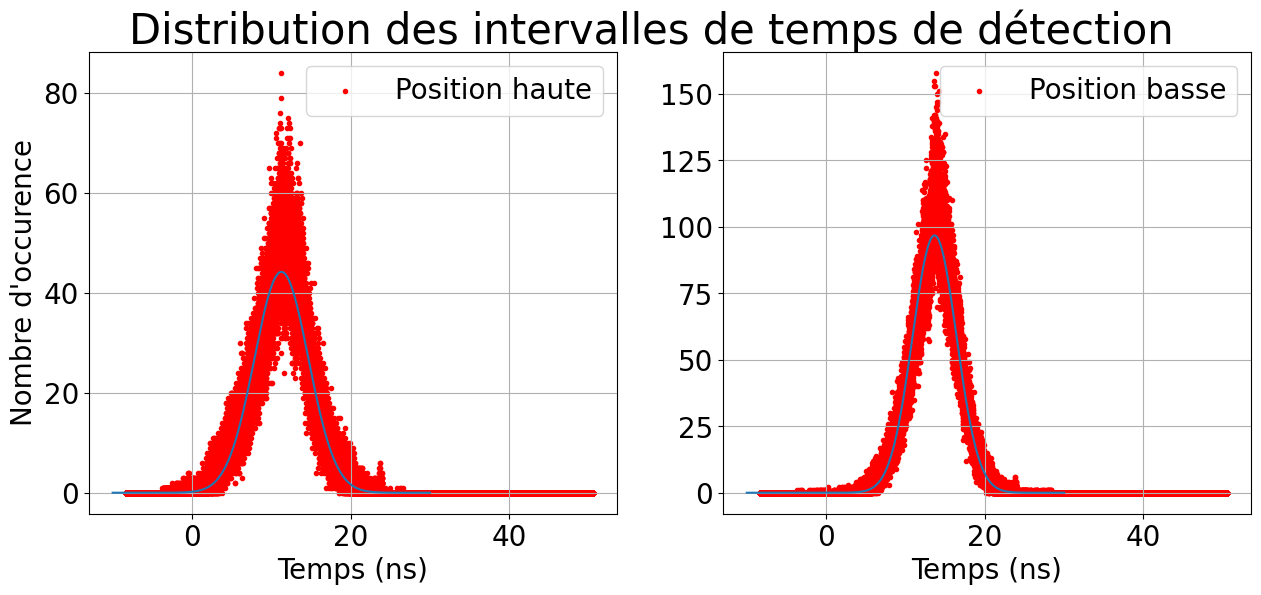

In [10]:
# Figures donnant le temps moyen de parcours en fonction de la position

data_up = time_average("haute", time, channel,cut = cuth)
data_low = time_average("basse", time, channel,cut = cutb)

fig, axs = plt.subplots(1, 2, figsize=(15, 6))  

axs[0].scatter(data_up[7], data_up[6], color = 'red', marker = '.', label = "Position haute")
axs[0].plot(np.linspace(-10, 30, 1000), gaussian(np.linspace(-10, 30, 1000), data_up[0], data_up[1], data_up[2],cut=cuth))
print(data_up[0], data_up[1], data_up[2])
axs[0].set_xlabel("Temps (ns)", fontsize = 20)
axs[0].set_ylabel("Nombre d'occurence", fontsize = 20)
axs[0].tick_params(axis='x', labelsize=20)
axs[0].tick_params(axis='y', labelsize=20)
axs[0].grid()
axs[0].legend(loc="best", fontsize = 20)

axs[1].scatter(data_low[7], data_low[6], color = 'red', marker = '.', label = "Position basse")
axs[1].plot(np.linspace(-10, 30, 1000), gaussian(np.linspace(-10, 30, 1000), data_low[0], data_low[1], data_low[2],cut=cutb))
axs[1].set_xlabel("Temps (ns)", fontsize = 20)
axs[1].tick_params(axis='x', labelsize=20)
axs[1].tick_params(axis='y', labelsize=20)
axs[1].grid()
axs[1].legend(loc="best", fontsize = 20)

fig.suptitle("Distribution des intervalles de temps de détection", fontsize = 30, ha = 'center', y = 0.95)
plt.show()


In [11]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.optimize as opt

# Modèle tronqué
def gaussian_cut(x, a, mu, sigma, cut=-np.inf):
    return np.where(x > cut, a * np.exp(-0.5 * ((x - mu) / sigma)**2), 0.0)

# Fonction chi²
def chi2(params, x, y, cut):
    a, mu, sigma = params
    model = gaussian_cut(x, a, mu, sigma, cut=cut)
    y_safe = np.where(y <= 0, np.nan, y)
    return np.nansum(((y - model)**2) / y_safe)

# Fit et affichage
def fit_gaussian_chi2(position, time, channel,cut=-np.inf,plot=True) : # Fonction calculant le temps moyen selon la position
    adujstment = calibration(time, channel)
    N = np.array(open_file(position))
    T = adujstment[0] * np.linspace(0, len(N), len(N)) + adujstment[1]
    
    init_guess = [np.max(N), T[np.argmax(N)], 1.0]
    bounds = [(0, None), (None, None), (1e-3, None)]

    result = opt.minimize(chi2, init_guess, args=(T, N, cut), method='L-BFGS-B', bounds=bounds)

    if not result.success:
        raise RuntimeError(f"Fit did not converge: {result.message}")

    a_fit, mu_fit, sigma_fit = result.x

    # Calcul du χ² et du χ² réduit
    chi2_val = chi2(result.x, T, N, cut)
    dof = np.sum((T > cut)&(N>0)) - 3  # nombre de degrés de liberté
    chi2_red = chi2_val / dof
    chi2_red_err = np.sqrt(2 / dof)

    print(f"Fit results:")
    print(f"  a     = {a_fit:.3f}")
    print(f"  mu    = {mu_fit:.3f}")
    print(f"  sigma = {sigma_fit:.3f}")
    print(f"  χ²/dof = {chi2_red:.2f} ± {chi2_red_err:.2f}  (χ² = {chi2_val:.1f}, dof = {dof})")

    if plot:
        x_fit = np.linspace(np.min(T), np.max(T), 1000)
        y_fit = gaussian_cut(x_fit, a_fit, mu_fit, sigma_fit, cut=cut)

        plt.figure(figsize=(8, 5))
        plt.plot(T, N, drawstyle='steps-mid', label='Données')
        plt.plot(x_fit, y_fit, 'r--', label='Fit gaussien')
        if cut > -np.inf:
            plt.axvline(cut, color='gray', linestyle=':', label='cut')
        plt.xlabel('Temps')
        plt.ylabel('Nombre de comptages')
        plt.title(f"Ajustement gaussien — χ²/dof = {chi2_red:.2f} ± {chi2_red_err:.2f}")
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.show()

    return a_fit, mu_fit, sigma_fit, chi2_red, chi2_red_err


Fit results:
  a     = 43.768
  mu    = 11.266
  sigma = 3.451
  χ²/dof = 1.31 ± 0.01  (χ² = 31935.7, dof = 24414)


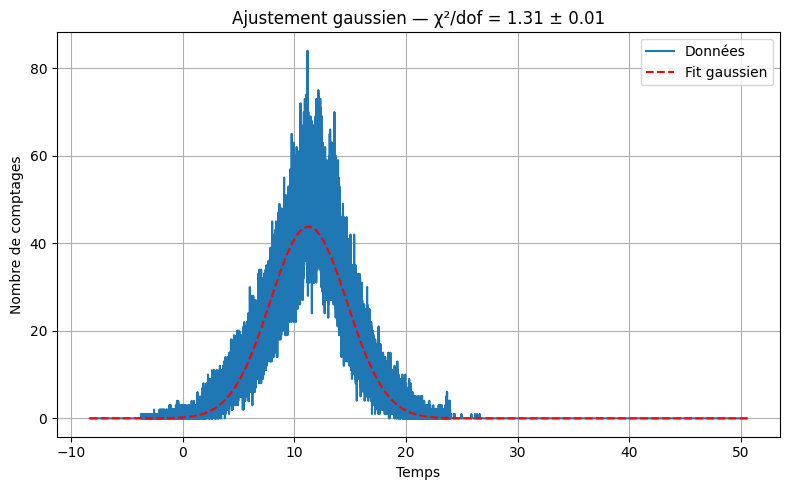

Fit results:
  a     = 96.350
  mu    = 13.671
  sigma = 2.794
  χ²/dof = 1.40 ± 0.01  (χ² = 29736.9, dof = 21272)


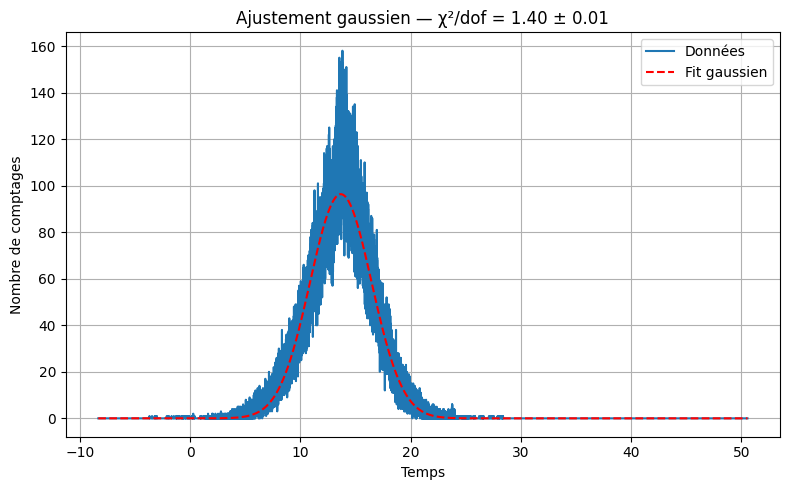

In [12]:
a_fit, mu_fit, sigma_fit, chi2_red, chi2_red_err = fit_gaussian_chi2("haute", time, channel,cut = cuth)
a_fit, mu_fit, sigma_fit, chi2_red, chi2_red_err = fit_gaussian_chi2("basse", time, channel,cut = cuth)

In [13]:

xmax = 0.20
ymax = 1.00
def f(theta) : ## Fonction cos(theta)**2 pour estimer la distance moyenne parcourue par les muons
    return (np.cos(theta))**2

def average_distance(distance,xmax=xmax,ymax=ymax,N=1000): # Fonction calculant la distance moyenne selon la position
    ## Simulation de la distance moyenne
    Ld = [] ## Liste des résultats pour la distance             
    Lt = [] ## Liste des résultats pour théta 
    i=0
    while i <N :
        x1 = rd.uniform(0, xmax)
        y1 = rd.uniform(0, ymax)
        phi = rd.uniform(0, 2*np.pi)
        theta = rd.uniform(-np.pi/2, np.pi/2)
        b = rd.uniform(0, 1)
        if f(theta) >= b: # Masque 
            Lt.append(theta)
            a = distance*np.tan(theta)
            x2 = x1+a*np.sin(phi)
            y2 = y1 + a*np.cos(phi)
            if 0 < x2 < xmax and 0 < y2 < ymax :
                Ld.append(distance*np.sqrt(1 + (np.tan(theta))**2))
                i+=1

    return Ld

def velocity(time, channel) : # Fonction calculant la vitesse moyenne des muons
    dh = get_distance('haute')
    db = get_distance('basse')
    v = (np.mean(average_distance(dh)) - np.mean(average_distance(db))) / np.abs(time_average("haute", time, channel)[1] - time_average("basse", time, channel)[1]) * 10**9
    
    return v 

In [14]:
# Détermination de la vitesse moyenne des muons

V = velocity(time, channel)

print("Vitesse moyenne des muons : " + str(int(V)) + " m/s")
print("Soit V  = " + str(np.round(V/299792458, 2)) + " c")

Vitesse moyenne des muons : 314973120 m/s
Soit V  = 1.05 c


In [15]:
# Erreurs sur les temps et les distances moyennes en utilisant les données des séances 2 et 3

t_up = data_up[1]
# delta_t_up = data_up[2]/np.sqrt(np.sum(data_up[6])) # error estimated using error on the mean formula
delta_t_up = data_up[4] # error from the fit

#delta_t_up = data_up[2]
print("t_up = (" + str(np.round(t_up, 3)) + " +/- " + str(np.round(delta_t_up, 3)) + ") ns")

t_low = data_low[1]
# delta_t_low = data_low[2]/np.sqrt(np.sum(data_low[6]))  # error estimated using error on the mean formula
delta_t_low = data_low[4]
print("t_low = (" + str(np.round(t_low, 3)) + " +/- " + str(np.round(delta_t_low, 3)) + ") ns")



t_up = (11.27 +/- 0.004) ns
t_low = (13.669 +/- 0.002) ns


In [16]:
dh = get_distance('haute')
db = get_distance('basse')
rg = np.random.default_rng()
dh_err_meas = 0.01
dh_err_meas = 0.01
M= 1000
N = 1000
d_up_sample=rg.normal(dh,dh_err_meas,size=M)
d_down_sample=rg.normal(db,dh_err_meas,size=M)

xmax_err = 0.01
xmax_sample=rg.normal(xmax,xmax_err,size=M)

ymax_err = 0.15
ymax_sample=rg.normal(ymax,ymax_err,size=M)

d_up_sample_tot = np.ones((M,N))
sigma_up_sample  = np.ones(M)
for i in range(M):
    d_up_sample_tot[i,:] = average_distance(d_up_sample[i],xmax = xmax_sample[i],ymax =ymax_sample[i], N=N)
    sigma_up_sample[i] = np.std(d_up_sample_tot[i])/np.sqrt(N)


d_down_sample_tot = np.ones((M,N))
sigma_down_sample  = np.ones(M)
for i in range(M):
    d_down_sample_tot[i,:] = average_distance(d_down_sample[i],xmax = xmax_sample[i],ymax =ymax_sample[i], N=N)
    sigma_down_sample[i] = np.std(sigma_down_sample[i])/np.sqrt(N)

(array([ 1.,  0.,  1.,  0.,  0.,  0.,  0.,  0.,  1.,  1.,  1.,  0.,  2.,
         1.,  0.,  0.,  1.,  1.,  0.,  3.,  2.,  3.,  2.,  1.,  2.,  4.,
         4.,  4.,  3.,  6.,  5., 12., 12., 15., 14.,  8., 15.,  8., 24.,
        22., 21., 19., 18., 20., 29., 23., 26., 20., 22., 20., 22., 26.,
        29., 20., 25., 26., 25., 32., 23., 25., 20., 27., 23., 32., 29.,
        26., 21., 15., 13., 16.,  9., 13., 15., 11., 13.,  7.,  7.,  6.,
         7.,  4.,  3.,  3.,  4.,  3.,  4.,  2.,  1.,  3.,  1.,  2.,  0.,
         2.,  4.,  0.,  0.,  1.,  0.,  1.,  0.,  2.]),
 array([0.39519993, 0.3959181 , 0.39663628, 0.39735445, 0.39807262,
        0.39879079, 0.39950897, 0.40022714, 0.40094531, 0.40166348,
        0.40238166, 0.40309983, 0.403818  , 0.40453617, 0.40525435,
        0.40597252, 0.40669069, 0.40740886, 0.40812704, 0.40884521,
        0.40956338, 0.41028155, 0.41099972, 0.4117179 , 0.41243607,
        0.41315424, 0.41387241, 0.41459059, 0.41530876, 0.41602693,
        0.4167451 , 0.4174

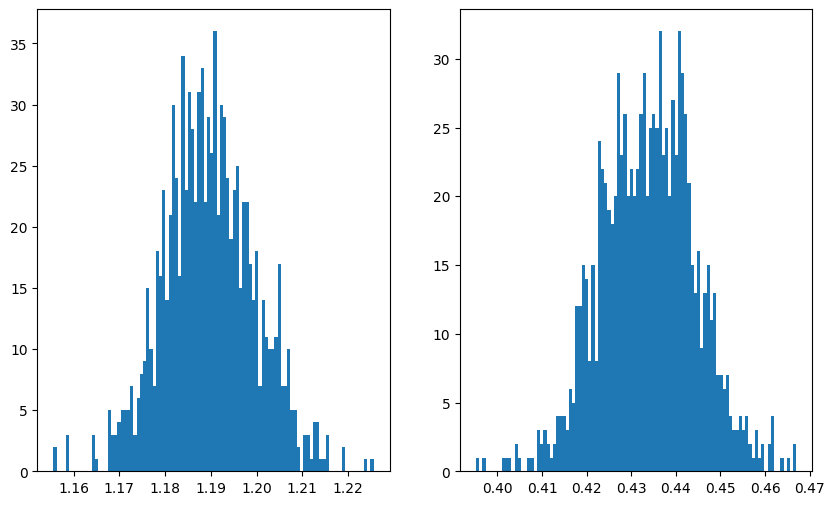

In [17]:
fig,ax = plt.subplots(1,2,figsize = (10,6))

ax[0].hist(np.mean(d_up_sample_tot,axis = 1),bins=100)
ax[1].hist(np.mean(d_down_sample_tot,axis = 1),bins=100)


In [18]:
delta_d_up = np.std(np.mean(d_up_sample_tot,axis = 1))

print(delta_d_up)
delta_d_up =np.sqrt(np.sum(sigma_up_sample**2))/M
delta_d_up = np.std(d_up_sample_tot)

d_up = np.mean(d_up_sample_tot)

delta_d_low =np.sqrt(np.sum(sigma_down_sample**2))/M

delta_d_low = np.std(d_down_sample_tot)
d_low = np.mean(d_down_sample_tot)


print("d_up = (" + str(d_up) + " +/- " + str(delta_d_up) + ") m")

#d_low = 0.434
#delta_d_low = 0.022 
print("d_low = (" + str(d_low) + " +/- " + str(delta_d_low) + ") m")


"""t_up = (11.27 +/- 3.409) ns
t_low = (13.669 +/- 2.778) ns
d_up = (1.189 +/- 0.026) m
d_low = (0.434 +/- 0.022) m
"""

0.00999833232377257
d_up = (1.1896850880167011 +/- 0.03970341289397084) m
d_low = (0.43388112246313165 +/- 0.04544542769757276) m


't_up = (11.27 +/- 3.409) ns\nt_low = (13.669 +/- 2.778) ns\nd_up = (1.189 +/- 0.026) m\nd_low = (0.434 +/- 0.022) m\n'

In [19]:
def velocity_error(d_up, d_low, delta_d_up, delta_d_low,
                      t_up, t_low, delta_t_up, delta_t_low,V):
    c = 299_792_458  # vitesse de la lumière en m/s

    # Grandeurs
    D = d_up - d_low
    T = np.abs(t_up - t_low)


    # Incertitudes sur D et T
    Delta_D = np.sqrt(delta_d_up**2 + delta_d_low**2)
    Delta_T = np.sqrt(delta_t_up**2 + delta_t_low**2)

    # Propagation d'incertitude
    delta_V = V * np.sqrt((Delta_D / D)**2 + (Delta_T / T)**2)

    #delta_V = V * np.sqrt((delta_t_up/t_up)**2 + (delta_t_low/t_low)**2 + (delta_d_up/d_up)**2 + (delta_d_low/d_low)**2)

    # Affichage
    print(f"D = {D:.6f} m ± {Delta_D:.6f} m")
    print(f"T = {T:.6e} s ± {Delta_T:.6e} s")
    print(f"V = ({V/1e8:.3f} ± {delta_V/1e8:.3f}) × 10⁸ m/s")
    print(f"V = ({V/c:.3f} ± {delta_V/c:.3f}) × c")
    print(f"ΔV/V = {delta_V / V * 100:.3f} %")

    return V, delta_V

velocity_error(d_up, d_low, delta_d_up, delta_d_low,
                  t_up, t_low, delta_t_up, delta_t_low,V)


D = 0.755804 m ± 0.060346 m
T = 2.398675e+00 s ± 4.396148e-03 s
V = (3.150 ± 0.252) × 10⁸ m/s
V = (1.051 ± 0.084) × c
ΔV/V = 7.986 %


(np.float64(314973120.0576232), np.float64(25155194.84032617))